Exercice 4

In [ ]:
import numpy as np

# Task 1: Creating a 5x5 matrix where border elements are 1 and interior is 0:
# Hint: Use np.ones and array slicing

matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0
print("Task 1 Output:\n", matrix)


# Task 2: Normalizing a random array:
np.random.seed(42)
random_data = np.random.randn(100, 3)

# Normalizing each column (mean=0, std=1):
mean = np.mean(random_data, axis=0)
std = np.std(random_data, axis=0)

normalized_data = (random_data - mean) / std

print("\nTask 2 Output (mean):", np.mean(normalized_data, axis=0))
print("Task 2 Output (std):", np.std(normalized_data, axis=0))


# Task 3: Implementing the linear regression solution using normal equation:
# theta = (X^T X)^(-1) X^T y

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# A normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTask 3 Output:")
print("Estimated theta:", theta_hat)
print("True theta:", true_theta)

Task 1 Output:
 [[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task 2 Output (mean): [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Task 2 Output (std): [1. 1. 1.]

Task 3 Output:
Estimated theta: [ 2.51723721 -1.19783796  3.72399266]
True theta: [ 2.5 -1.2  3.7]


Exercise 5: Pandas Data Analysis

In [2]:
import pandas as pd
import numpy as np

# Creating a sample dataset:
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),  # fixed typo
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introducing some NaN values:
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration
# Displaying the basic information:
print("Dataset Info:")
print(df.info())

# Counting the missing values:
print("\nMissing Values:")
print(df.isnull().sum())

# Filling the missing exam_score with mean per major:
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Filling the missing hours_studied with median per year:
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

# Task 2: Analysis
# Calculating the average exam score by major:
avg_by_major = df.groupby('major')['exam_score'].mean()
print("\nAverage exam score by major:")
print(avg_by_major)

# Calculating the major with highest average:
top_major = avg_by_major.idxmax()
print("\nMajor with highest average exam score:", top_major)

# The correlation:
correlation = df['hours_studied'].corr(df['exam_score'])
print("\nCorrelation between hours studied and exam score:", correlation)

# The performance column:
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)

# Task 3: Advanced Analysis
# Grouping the group by major and year:
grouped = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours=('hours_studied', 'mean')
)
print("\nGrouped Analysis:")
print(grouped)

# Taking the top 5 students:
top_5 = df.nlargest(5, 'exam_score')
print("\nTop 5 students:")
print(top_5[['student_id', 'exam_score']])

# Pivot table: 
pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table (Average exam score by major and year):")
print(pivot)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None

Missing Values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Average exam score by major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with highest average exam score: CS

Correlati

Exercise 6: Data Visualization

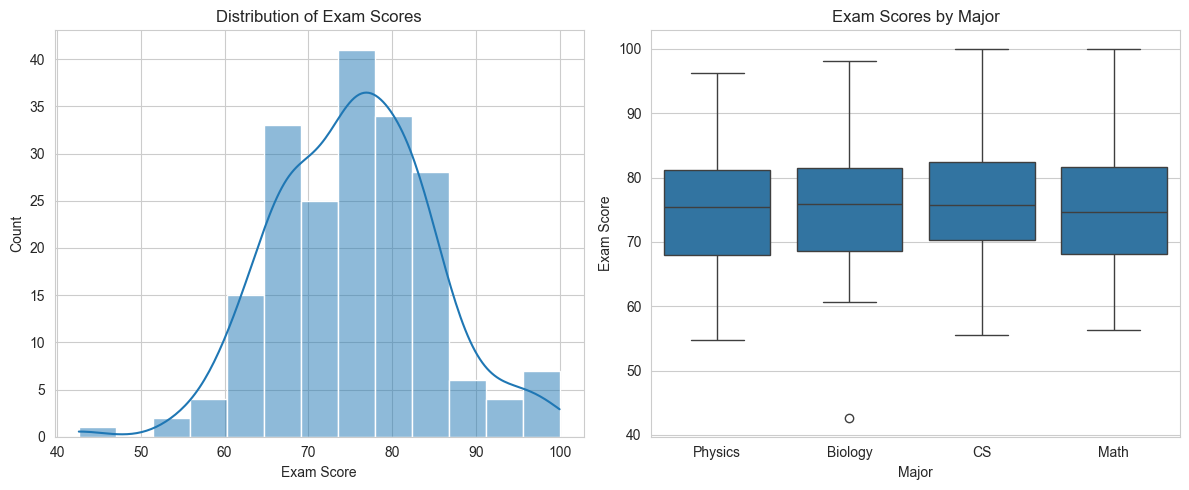

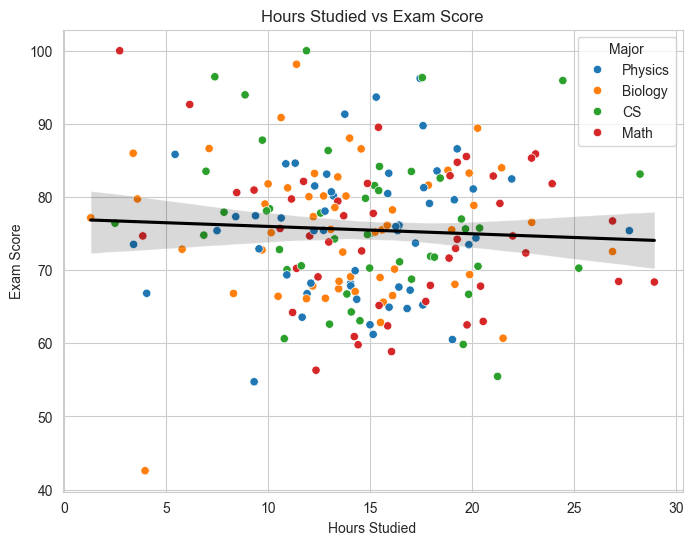

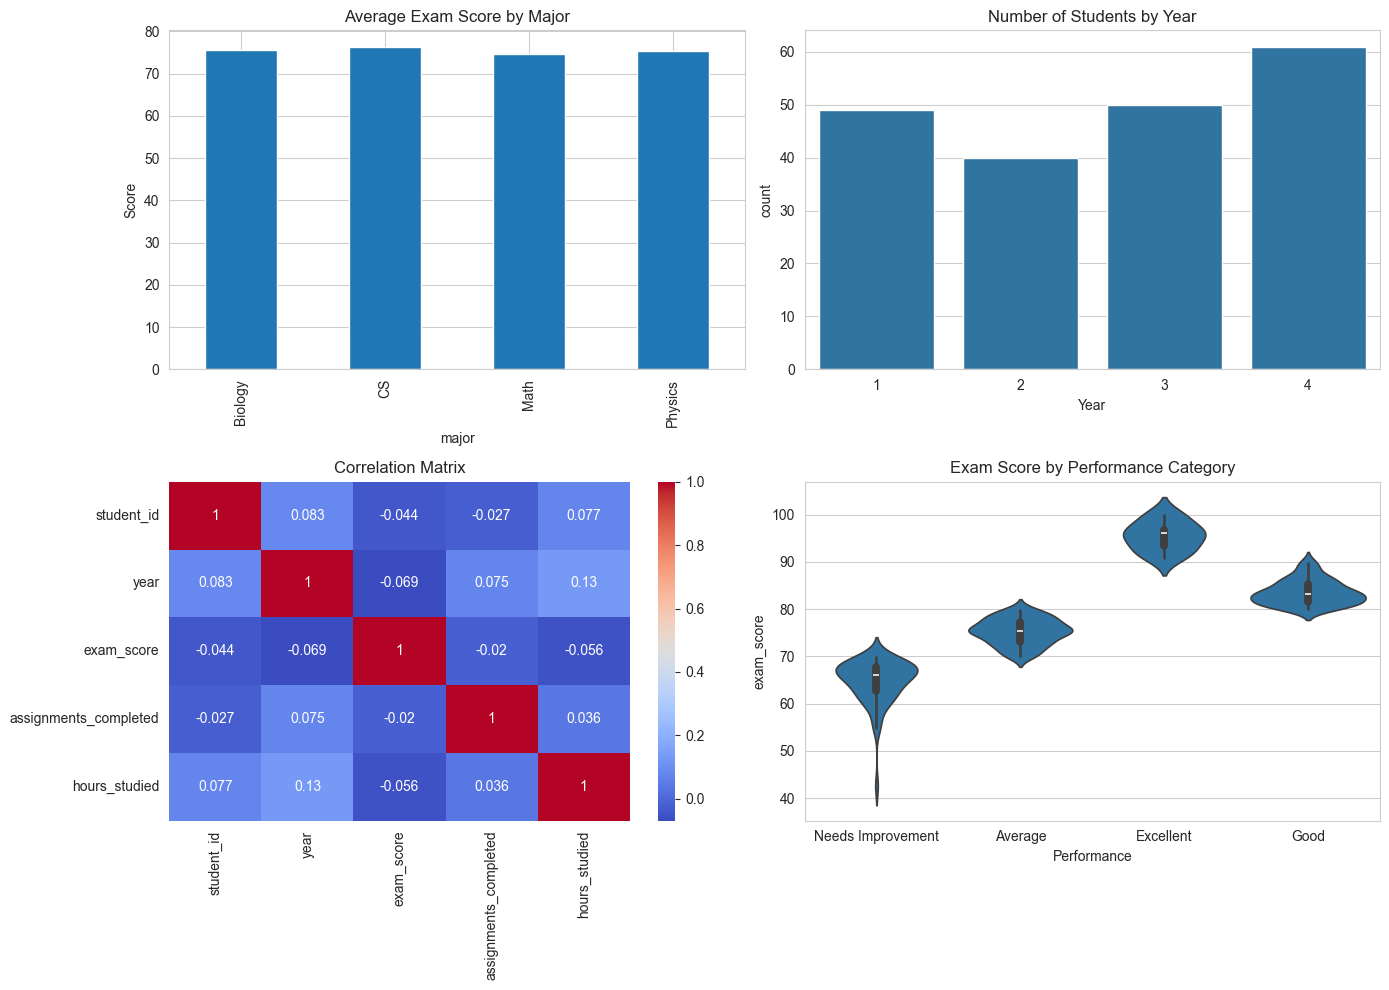

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the style for better visuals:
sns.set_style("whitegrid")

# Task 1: Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Histogram with KDE:
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")

# Right: Box plot by major:
sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1])
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

# The regression line:
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black'
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

# Task 3: Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
avg_major = df.groupby('major')['exam_score'].mean()
avg_major.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_ylabel("Score")

# 2. Count plot: students by year:
sns.countplot(x='year', data=df, ax=axes[0, 1])
axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")

# 3. Heatmap: correlation matrix:
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title("Correlation Matrix")

# 4. Violin plot: performance vs exam score:
sns.violinplot(x='performance', y='exam_score', data=df, ax=axes[1, 1])
axes[1, 1].set_title("Exam Score by Performance Category")
axes[1, 1].set_xlabel("Performance")

plt.tight_layout()
plt.show()

Exercise 7: Integration Challenge


Age Group Analysis:
           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683

Top 10% Customers:
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663 

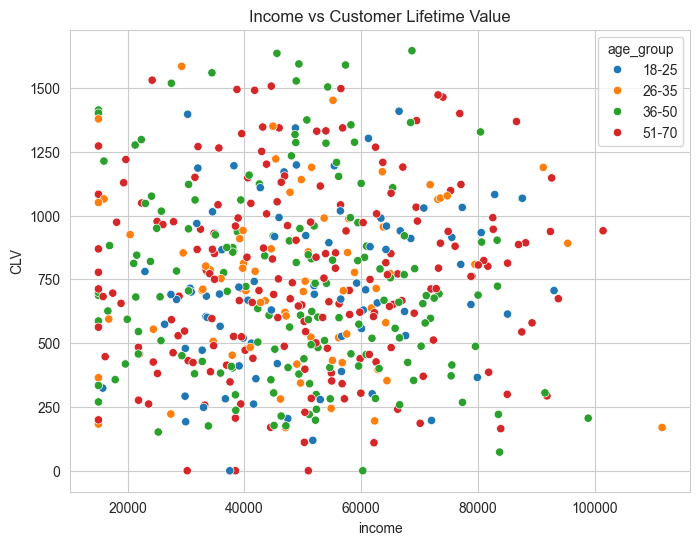

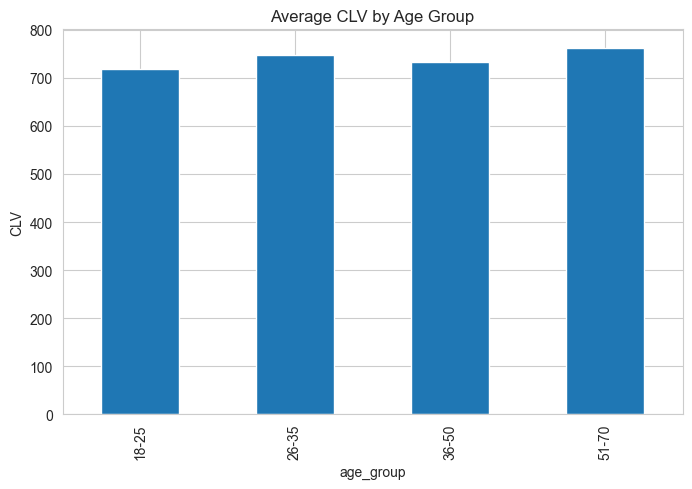

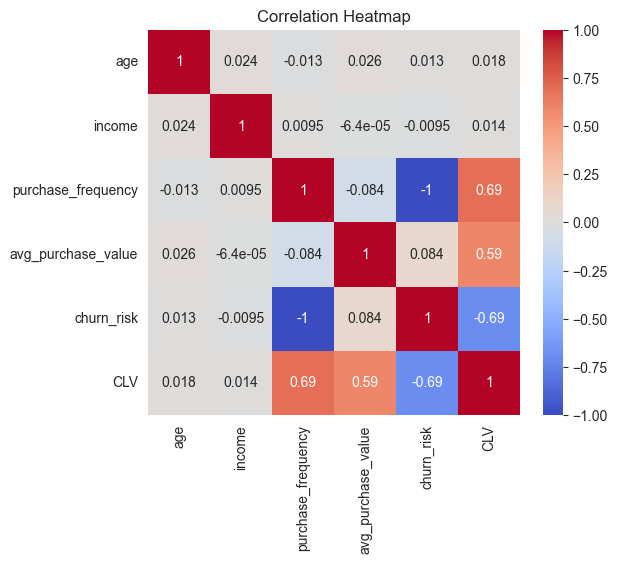

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generating the customer data:
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Creating the DataFrame:
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculating customer lifetime value (CLV):
max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

# Age Groups:
bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True)

# Group Analysis:
group_analysis = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)
print("\nAge Group Analysis:")
print(group_analysis)

# Identifying the top 10% Customers by CLV:
threshold = customers['CLV'].quantile(0.9)
top_customers = customers[customers['CLV'] >= threshold]
print("\nTop 10% Customers:")
print(top_customers.head())

# Creating visualizations:
sns.set_style("whitegrid")

# 1. Scatter plot: Income vs CLV
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)
plt.title("Income vs Customer Lifetime Value")
plt.show()

# 2. Bar chart: Average CLV by age group
plt.figure(figsize=(8, 5))
customers.groupby('age_group')['CLV'].mean().plot(kind='bar')
plt.title("Average CLV by Age Group")
plt.ylabel("CLV")
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(6, 5))
corr = customers.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()